In [ ]:
!pip install efficientnet_pytorch

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from efficientnet_pytorch import EfficientNet
from PIL import Image
import json
import requests
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


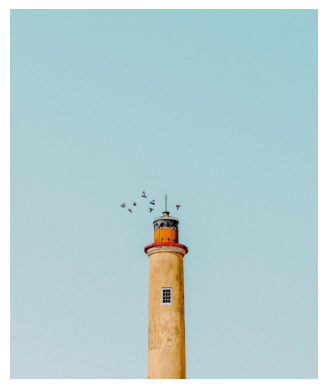

In [8]:
image_path = "/content/drive/MyDrive/Colab Notebooks/"
image = Image.open(image_path+"04.jpg")
plt.imshow(image)
plt.axis("off")  # 축 제거
plt.show()

In [9]:
import json

Loaded pretrained weights for efficientnet-b0
beacon: 83.80%
breakwater: 4.11%
mosque: 1.37%
bell_cote: 1.24%
water_tower: 0.55%


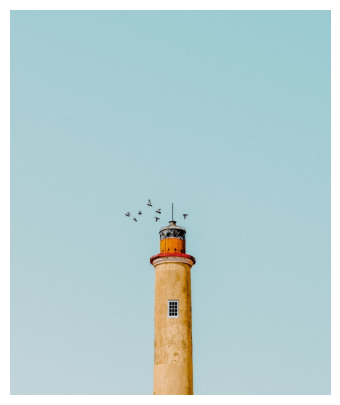

In [10]:
#ImageNet 클래스 매핑
imagenet_json_path = "/content/drive/MyDrive/Colab Notebooks/imagenet.json"

with open(imagenet_json_path, "r") as f:
    imagenet_classes = json.load(f)

#모델 로드
model = EfficientNet.from_pretrained('efficientnet-b0')
model.eval()


def preprocess_image(image_path, image_size):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  #사이즈 맞게 정리
    ])

    image = Image.open(image_path).convert('RGB')  #PIL 이미지로 변환
    image = transform(image)
    image = image.unsqueeze(0)  #배치 차원 수정

    return image

#추론 함수
def inference(model, image_path):
    image_size = model._conv_stem.weight.shape[2]
    input_tensor = preprocess_image(image_path, image_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    input_tensor = input_tensor.to(device)

    # 추론 수행
    with torch.no_grad():
        output = model(input_tensor)

    # 결과 해석
    probabilities = torch.nn.functional.softmax(output[0], dim=0)  # 소프트맥스 적용
    top5_prob, top5_catid = torch.topk(probabilities, 5)  # 상위 5개 클래스 추출

    for i in range(5):
        class_idx = str(top5_catid[i].item())
        class_name = imagenet_classes[class_idx][1]
        print(f"{class_name}: {top5_prob[i].item() * 100:.2f}%")

    # 원본 이미지 출력
    image = Image.open(image_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# 실행
inference(model, image_path+"04.jpg")

breakwater: 79.23%
maze: 6.20%
seashore: 0.45%
promontory: 0.41%
beacon: 0.35%


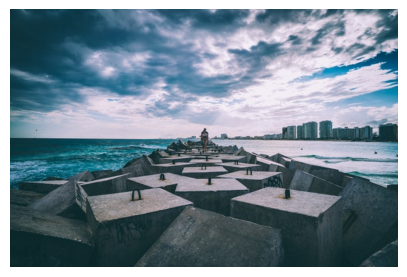

In [14]:
inference(model, image_path+"05.jpg")

In [12]:
model = EfficientNet.from_pretrained('efficientnet-b7')
model.eval()

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b7-dcc49843.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b7-dcc49843.pth
100%|██████████| 254M/254M [00:02<00:00, 111MB/s]


Loaded pretrained weights for efficientnet-b7


EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        64, 16, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        16, 64, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False
  

cocker_spaniel: 36.04%
English_setter: 13.61%
cheetah: 7.28%
studio_couch: 6.29%
Maltese_dog: 2.71%


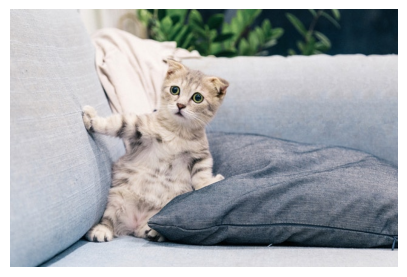

In [13]:
inference(model, image_path+"cat.jpg")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 13.6M/13.6M [00:00<00:00, 51.1MB/s]


beacon: 88.92%
breakwater: 6.80%
bell_cote: 2.25%
mosque: 0.27%
birdhouse: 0.25%


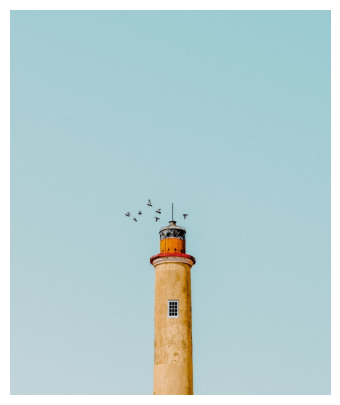

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 75.6MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image
import json
import requests
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

# ImageNet 클래스 매핑
imagenet_json_path = "/content/drive/MyDrive/Colab Notebooks/imagenet.json"

with open(imagenet_json_path, "r") as f:
    imagenet_classes = json.load(f)

# MobileNet 모델 로드
model = models.mobilenet_v2(pretrained=True)
model.eval()

def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 정규화
    ])

    image = Image.open(image_path).convert('RGB')  # PIL 이미지로 변환
    image = transform(image)
    image = image.unsqueeze(0)  # 배치 차원 추가

    return image

# 추론 함수
def inference(model, image_path):
    input_tensor = preprocess_image(image_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    input_tensor = input_tensor.to(device)

    # 추론 수행
    with torch.no_grad():
        output = model(input_tensor)

    # 결과 해석
    probabilities = torch.nn.functional.softmax(output[0], dim=0)  # 소프트맥스 적용
    top5_prob, top5_catid = torch.topk(probabilities, 5)  # 상위 5개 클래스 추출

    for i in range(5):
        class_idx = str(top5_catid[i].item())
        class_name = imagenet_classes[class_idx][1]
        print(f"{class_name}: {top5_prob[i].item() * 100:.2f}%")

    # 원본 이미지 출력
    image = Image.open(image_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# 실행
image_path = "/content/drive/MyDrive/Colab Notebooks/04.jpg"
inference(model, image_path)

# MobileNetV3 Large로 변경 (선택 사항)
model = models.mobilenet_v3_large(pretrained=True)
model.eval()


breakwater: 96.40%
maze: 1.32%
pier: 0.44%
dock: 0.43%
lakeside: 0.18%


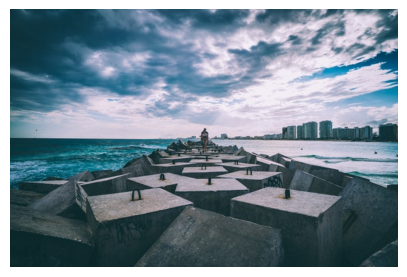

In [16]:
# 실행
image_path = "/content/drive/MyDrive/Colab Notebooks/05.jpg"
inference(model, image_path)

Maltese_dog: 17.88%
Egyptian_cat: 17.14%
toy_poodle: 15.01%
Yorkshire_terrier: 11.73%
Norfolk_terrier: 8.35%


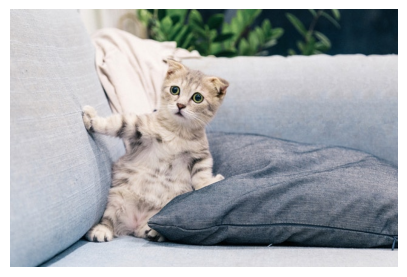

In [18]:
# 실행
image_path = "/content/drive/MyDrive/Colab Notebooks/cat.jpg"
inference(model, image_path)